# Analysis: topographic W_in model (`BioLeakyRNNTopo`)

Copy of `02_analysis.ipynb` that loads the model trained in
`01c_train_topo.ipynb` (checkpoint `stage2_topo.pt`,
`hidden_size=144`, `exc_ratio=100/144`, `use_topo_input=True`).

Extra cell at the end: `plot_topo_input(model)` to see how training
reshapes the topographic W_in.


In [1]:
import sys

sys.path.insert(0, "..")

import torch
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

from src.model_topo import BioLeakyRNNTopo
from src.plotting_topo import plot_rf_drive, plot_sheet_layout, plot_fix_weights
from src.env import CuedTargetWithDistractorsV3
from src.analysis import (
    collect_trials,
    filter_trials,
    select_trials,
    fit_pca_on_trials,
    get_aligned_pca_segments,
    compute_median_and_band,
    compute_mean_and_sem,
    dpca_marginals,
    collect_aligned_hidden_by_label,
    make_condition_mean_tensor,
    plot_spatial_separation_pca,
    print_centroid_distances,
    compare_spatial_separation,
)
from src.plotting import (
    plot_pca_trajectories,
    plot_pca_trajectories_by_outcome,
    plot_pc_timecourses,
    plot_two_group_pc_timecourses,
    plot_two_group_median_trajectories,
    plot_trialtype_panel,
    plot_dpca_components,
    plot_dpca_plane,
)

device = "cpu"
print("device:", device)
from src.analysis import plot_spatial_map, plot_connectivity_matrix

device: cpu


## Ablation: stim_on and cue_on removed

Training uses `NoTimingMarkersEnv` — a subclass of `CuedTargetWithDistractorsV3`
that zeros **both** the `cue_on` (channel 1) and `stim_on` (channel 4)
channels in every trial. This removes two shortcut signals that earlier
trainings exploited:
- `stim_on` was used as a pure timing marker for target detection
  (original ablation in the previous iteration).
- `cue_on` was used as a pure timing marker for the cue epoch — lesion
  tests showed the network relied on it (zeroing it dropped accuracy
  0.80 → 0.39) without actually decoding *where* the cue pointed
  (zeroing `cue_x/cue_y` left accuracy at 0.81).

With both markers absent, the only way to detect either the cue epoch
or the target is via non-zero `cue_x/cue_y` or `stim_x/stim_y` drive
through the frozen topographic `W_in_topo`, so the network is forced to
use spatial structure for both events.

The environment source (`src/env.py`) is untouched — the ablation is a
notebook-only subclass.


## Load model

In [3]:
def make_model():
    return BioLeakyRNNTopo(
        input_size=7,
        hidden_size=180,
        output_size=2,
        dt=20.0,
        tau=100.0,
        activation="softplus",
        sigma_rec=0.10,
        rec_init="diag",
        use_ei=True,
        exc_ratio=0.80,
        use_dale=True,
        mask_seed=42,
        sheet_side=12,
        tau_ee=0.25,
        tau_ie=0.32,
        tau_ei=0.64,
        tau_ii=0.64,
        rf_sigma=0.3,
    )


def make_env_stage2():
    return CuedTargetWithDistractorsV3(
        dt=20,
        cue_strength=1.0,
        p_distractor_trial=0.6,
        distractor_strength=1.0,
        continuous_locations=True,
    )


model = make_model().to(device)
model.load_state_dict(
    torch.load("../checkpoints/stage2_topo.pt", weights_only=True)["state_dict"],
    strict=False,
)
model.eval()
print("Loaded stage2_topo checkpoint.")

Loaded stage2_topo checkpoint.


## Collect trials

In [4]:
trials = collect_trials(model, make_env_stage2, n_trials=2000, device=device)
print(f"Collected {len(trials)} trials")
print(Counter(tr["train_outcome"] for tr in trials))

Collected 2000 trials
Counter({'correct': 1910, 'false_alarm': 38, 'abort': 37, 'miss': 15})


## PCA on hidden states

In [5]:
pca, trial_proj, explained = fit_pca_on_trials(trials, n_components=3)
print("Explained variance:", explained)

Explained variance: [0.60165097 0.14462275 0.10377379]


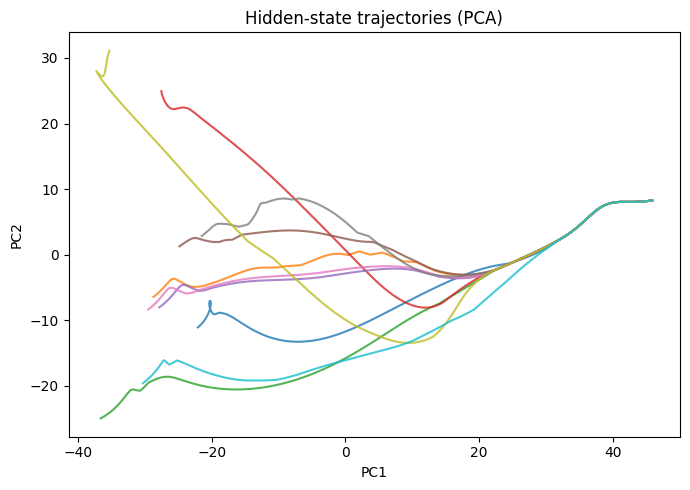

In [6]:
plot_pca_trajectories(trials, trial_proj, max_trials=10)

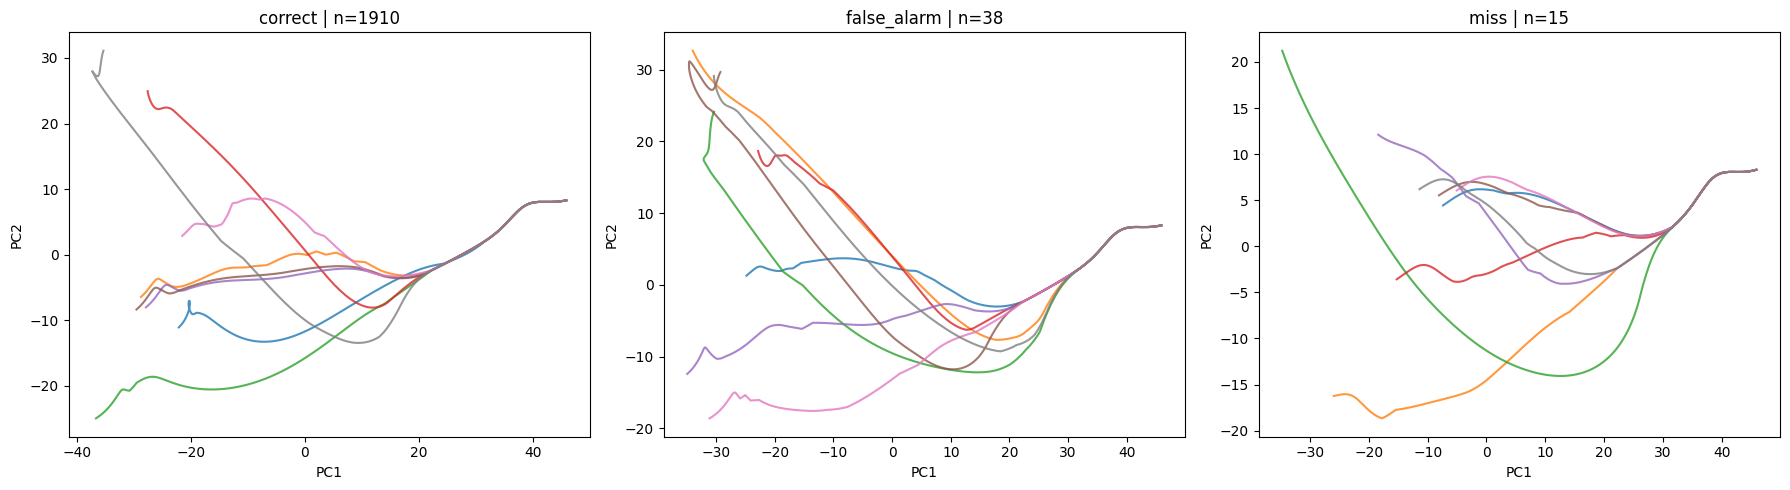

In [7]:
plot_pca_trajectories_by_outcome(
    trials, trial_proj, outcomes=("correct", "false_alarm", "miss"), max_per_group=8
)

## Event-aligned time courses

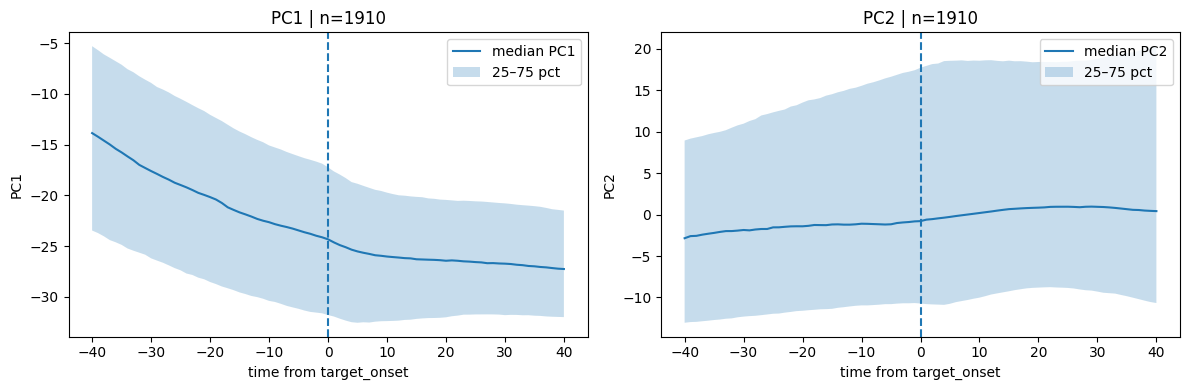

In [8]:
plot_pc_timecourses(
    trials,
    trial_proj,
    align_key="target_onset",
    window_before=40,
    window_after=40,
    stat_mode="median",
    q_low=25,
    q_high=75,
    train_outcome="correct",
)

In [9]:
# PC1/PC2/PC3 time courses per CTOA bin — matches paper Figure
# 10 lines (one per CTOA bin, light→dark blue), aligned to target onset
from src.analysis import get_aligned_pca_segments

n_bins = 10
colors = plt.cm.Blues(np.linspace(0.3, 1.0, n_bins))
window_before, window_after = 20, 20  # steps = 400ms each side

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)
pc_names = ["PC1", "PC2", "PC3"]

for b in range(n_bins):
    aligned, rel_time, kept = get_aligned_pca_segments(
        trials,
        trial_proj,
        align_key="target_onset",
        window_before=window_before,
        window_after=window_after,
        train_outcome="correct",
        ctoa_bin_min=b,
        ctoa_bin_max=b,
    )
    if aligned is None or len(aligned) < 3:
        continue
    center = np.median(aligned, axis=0)  # [T, n_components]
    rel_ms = rel_time * 20  # steps -> ms
    for k, ax in enumerate(axes):
        ax.plot(rel_ms, center[:, k], color=colors[b], linewidth=1.5, alpha=0.85)

for k, ax in enumerate(axes):
    ax.axvline(0, linestyle="--", color="gray", linewidth=1)
    ax.set_xlabel("Time (ms)")
    ax.set_ylabel("Firing Rate")
    ax.set_title(pc_names[k])
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

sm = plt.cm.ScalarMappable(cmap="Blues", norm=plt.Normalize(0, n_bins - 1))
sm.set_array([])
fig.colorbar(sm, ax=axes[-1], label="CTOA bin (0=short, 9=long)", shrink=0.8)
plt.suptitle("PCA trajectories by CTOA bin (target-locked)", y=1.02)
plt.tight_layout()
plt.show()

IndentationError: expected an indented block after 'for' statement on line 12 (2955785488.py, line 13)

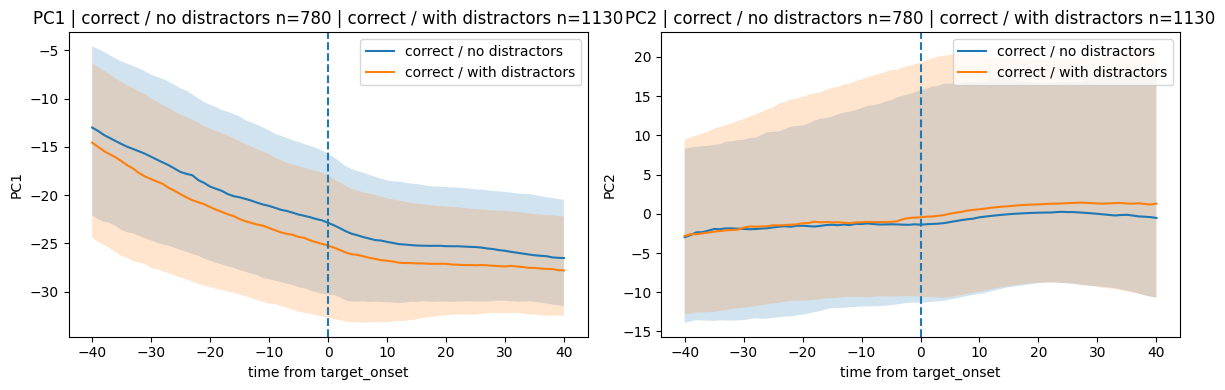

In [10]:
plot_two_group_pc_timecourses(
    trials,
    trial_proj,
    align_key="target_onset",
    window_before=40,
    window_after=40,
    group1_kwargs={"train_outcome": "correct", "has_distractors": False},
    group2_kwargs={"train_outcome": "correct", "has_distractors": True},
    group1_label="correct / no distractors",
    group2_label="correct / with distractors",
    stat_mode="median",
    q_low=25,
    q_high=75,
)

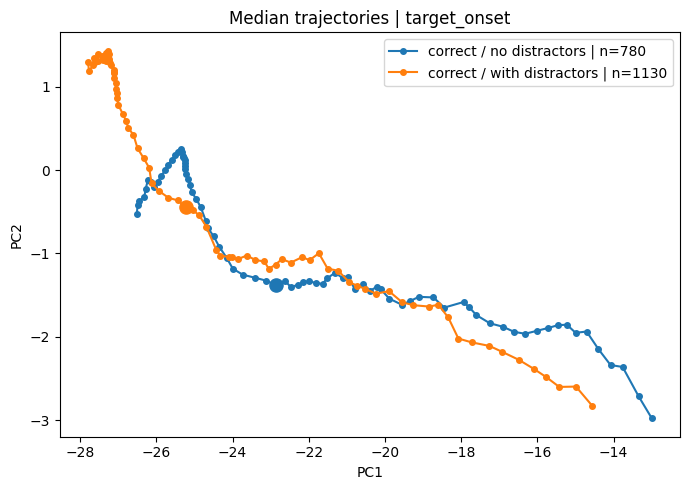

In [11]:
plot_two_group_median_trajectories(
    trials,
    trial_proj,
    align_key="target_onset",
    window_before=40,
    window_after=40,
    group1_kwargs={"train_outcome": "correct", "has_distractors": False},
    group2_kwargs={"train_outcome": "correct", "has_distractors": True},
    group1_label="correct / no distractors",
    group2_label="correct / with distractors",
)

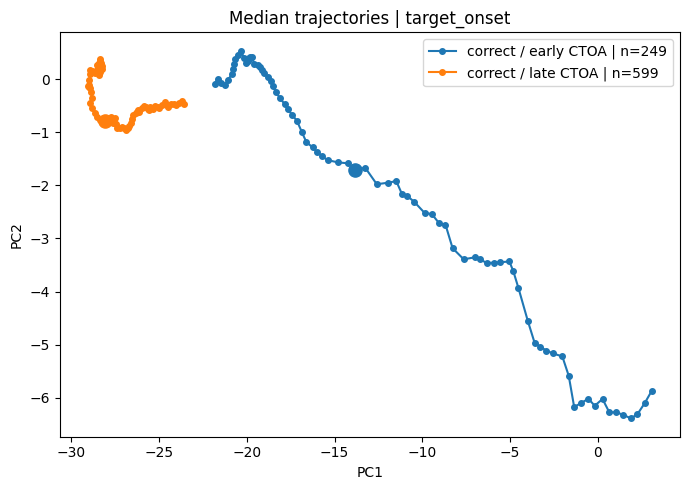

In [12]:
plot_two_group_median_trajectories(
    trials,
    trial_proj,
    align_key="target_onset",
    window_before=40,
    window_after=40,
    group1_kwargs={"train_outcome": "correct", "ctoa_bin_max": 2},
    group2_kwargs={"train_outcome": "correct", "ctoa_bin_min": 7},
    group1_label="correct / early CTOA",
    group2_label="correct / late CTOA",
)

## Panel: outcomes × CTOA × spatial location

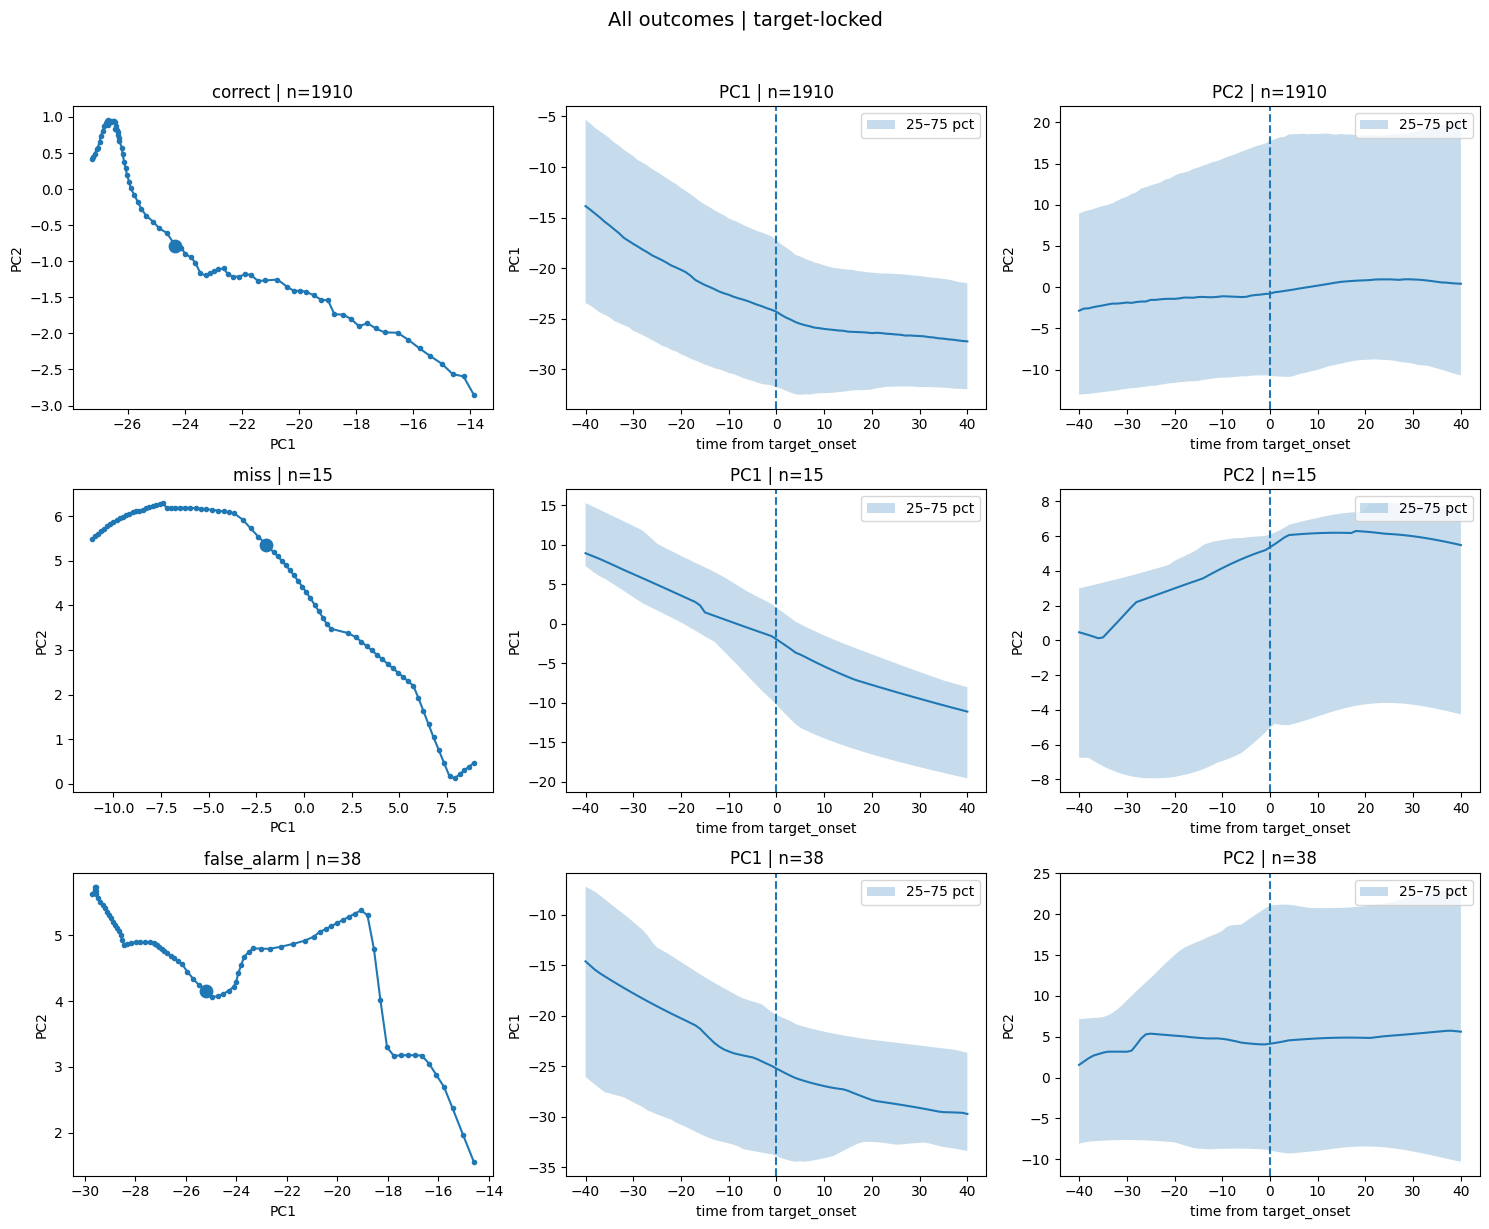

In [13]:
plot_trialtype_panel(
    trials,
    trial_proj,
    group_specs=[
        {"label": "correct", "train_outcome": "correct"},
        {"label": "miss", "train_outcome": "miss"},
        {"label": "false_alarm", "train_outcome": "false_alarm"},
    ],
    align_key="target_onset",
    window_before=40,
    window_after=40,
    stat_mode="median",
    q_low=25,
    q_high=75,
    suptitle="All outcomes | target-locked",
)

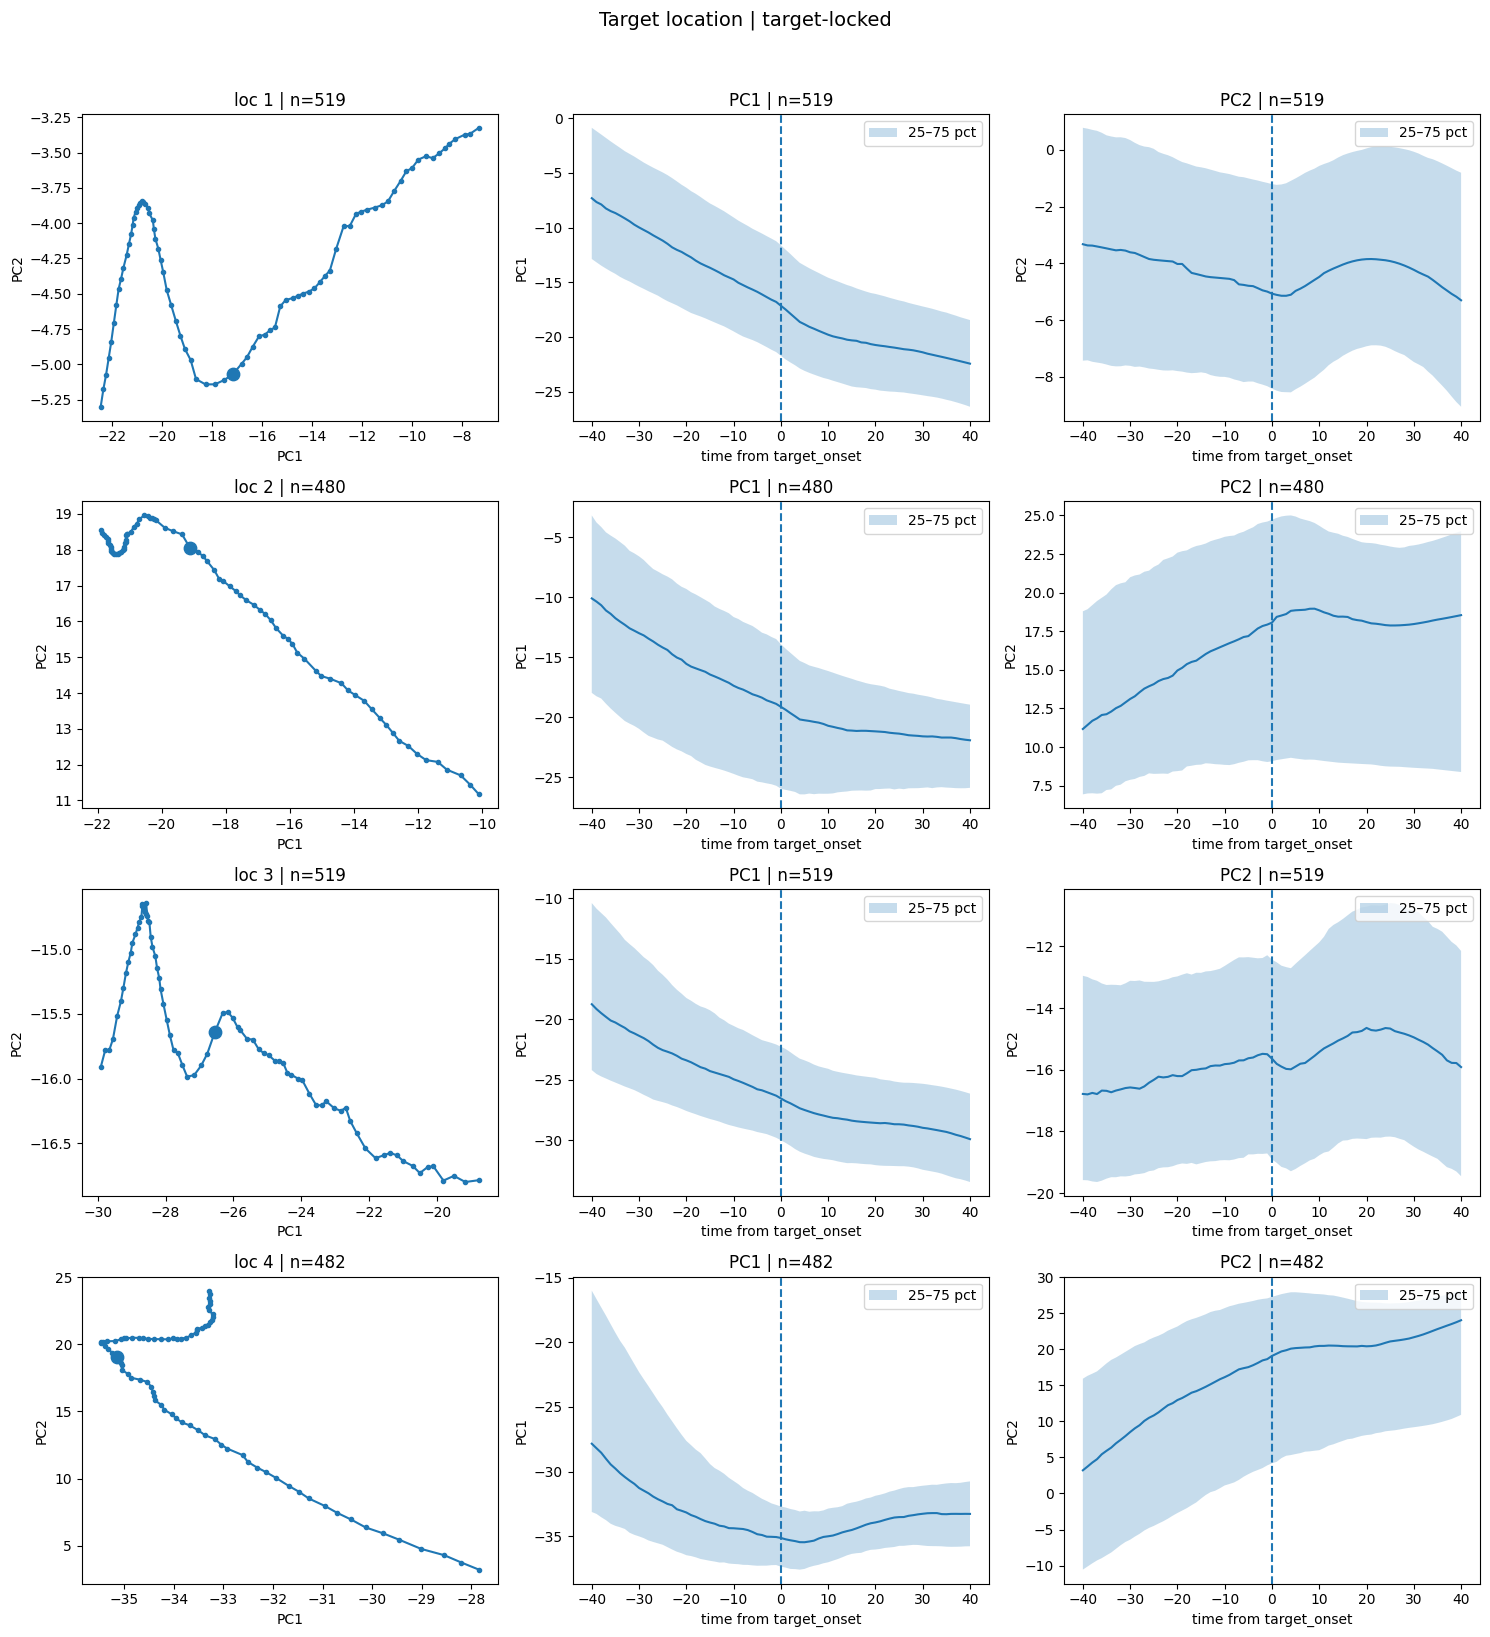

In [14]:
plot_trialtype_panel(
    trials,
    trial_proj,
    group_specs=[{"label": f"loc {i}", "target_loc": i} for i in range(1, 5)],
    align_key="target_onset",
    window_before=40,
    window_after=40,
    stat_mode="median",
    q_low=25,
    q_high=75,
    suptitle="Target location | target-locked",
)

## False alarms vs aborts

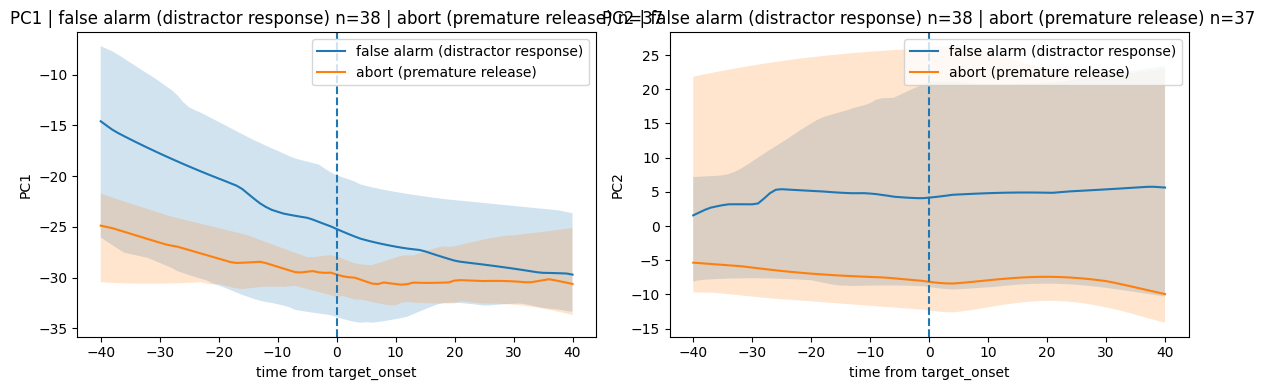

In [15]:
plot_two_group_pc_timecourses(
    trials,
    trial_proj,
    align_key="target_onset",
    window_before=40,
    window_after=40,
    group1_kwargs={"train_outcome": "false_alarm"},
    group2_kwargs={"train_outcome": "abort"},
    group1_label="false alarm (distractor response)",
    group2_label="abort (premature release)",
    stat_mode="median",
    q_low=25,
    q_high=75,
)

## dPCA: CTOA condition

In [16]:
by_ctoa, rel_time = collect_aligned_hidden_by_label(
    trials,
    label_fn=lambda tr: tr.get("ctoa_bin"),
    align_key="target_onset",
    window_before=40,
    window_after=40,
)
X_ctoa, ctoa_labels, ctoa_counts = make_condition_mean_tensor(by_ctoa, min_trials=5)
print("CTOA bins:", ctoa_labels, "  counts:", ctoa_counts)

res_ctoa = dpca_marginals(X_ctoa, n_components=3)
res_ctoa["rel_time"] = rel_time
res_ctoa["labels"] = ctoa_labels

CTOA bins: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]   counts: [23, 82, 160, 176, 278, 328, 304, 260, 271, 118]


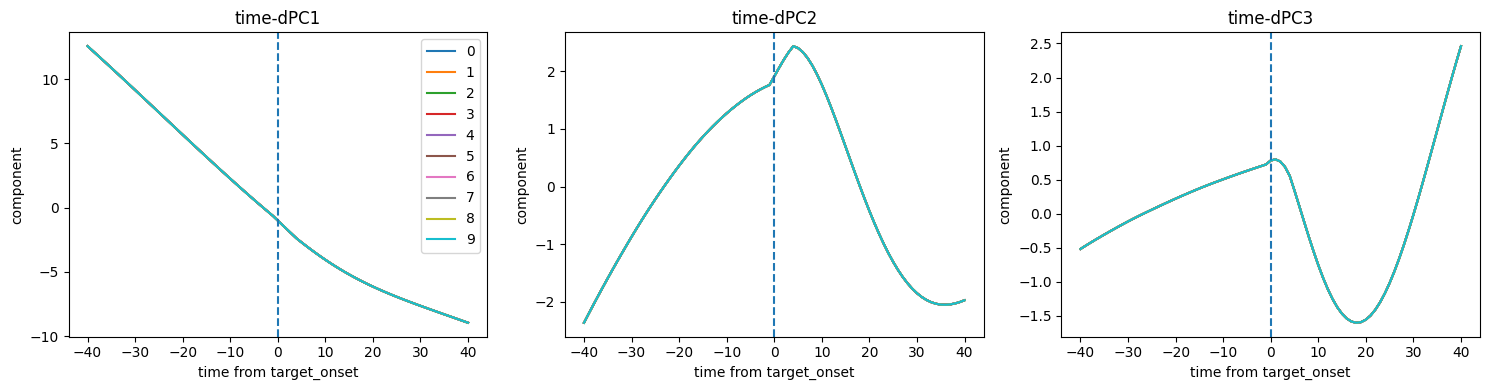

Explained variance (time): [0.9307209 0.0473268 0.0165338]


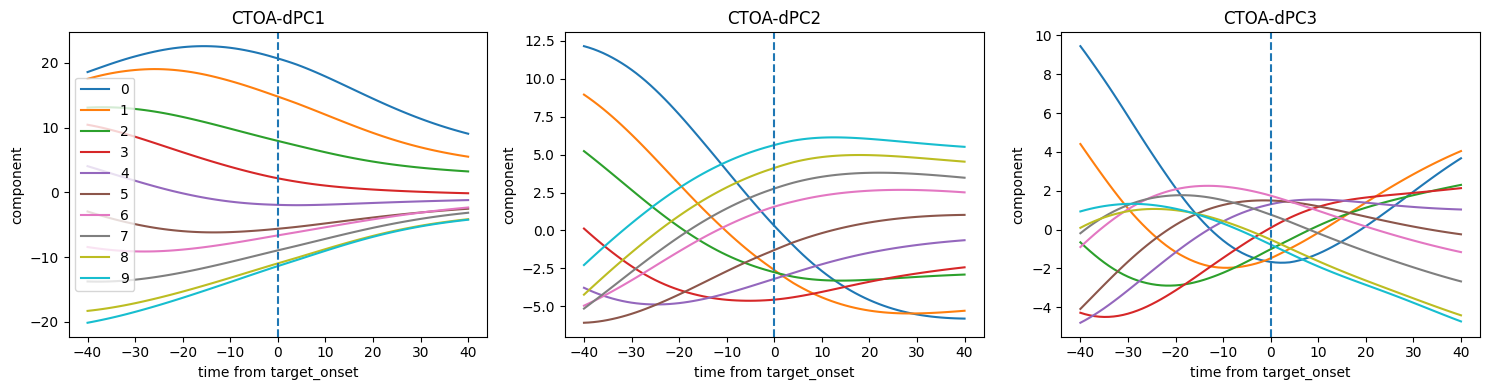

Explained variance (CTOA): [0.8210721  0.11770072 0.03312165]


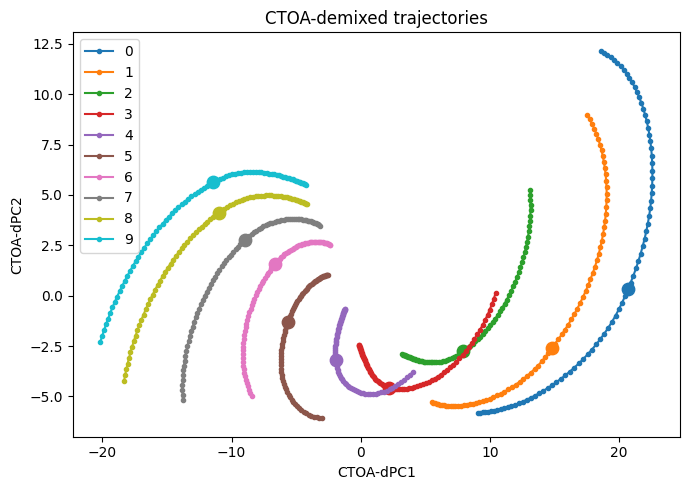

In [17]:
plot_dpca_components(
    res_ctoa,
    component_key="Z_time",
    explained_key="explained_time",
    title_prefix="time",
    n_plot=3,
)
plot_dpca_components(
    res_ctoa,
    component_key="Z_cond",
    explained_key="explained_cond",
    title_prefix="CTOA",
    n_plot=3,
)
plot_dpca_plane(
    res_ctoa, xlabel="CTOA-dPC1", ylabel="CTOA-dPC2", title="CTOA-demixed trajectories"
)

## CTOA x target position

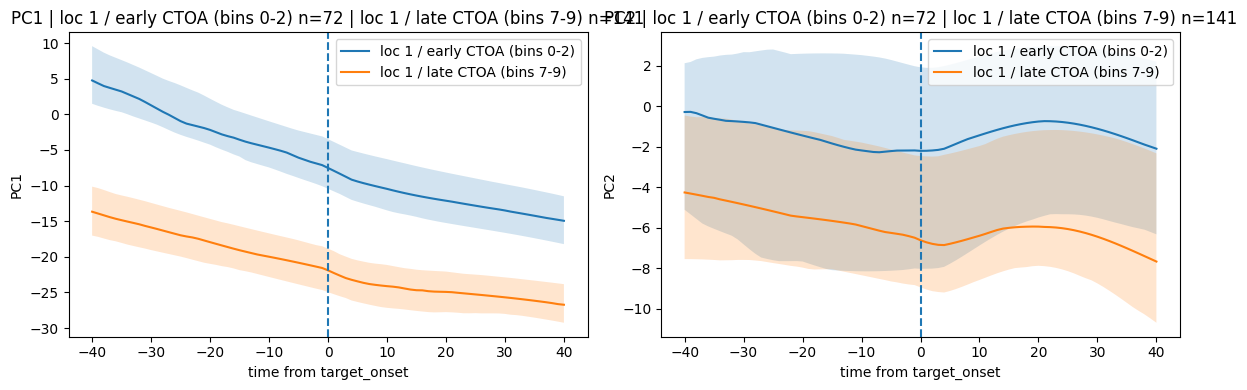

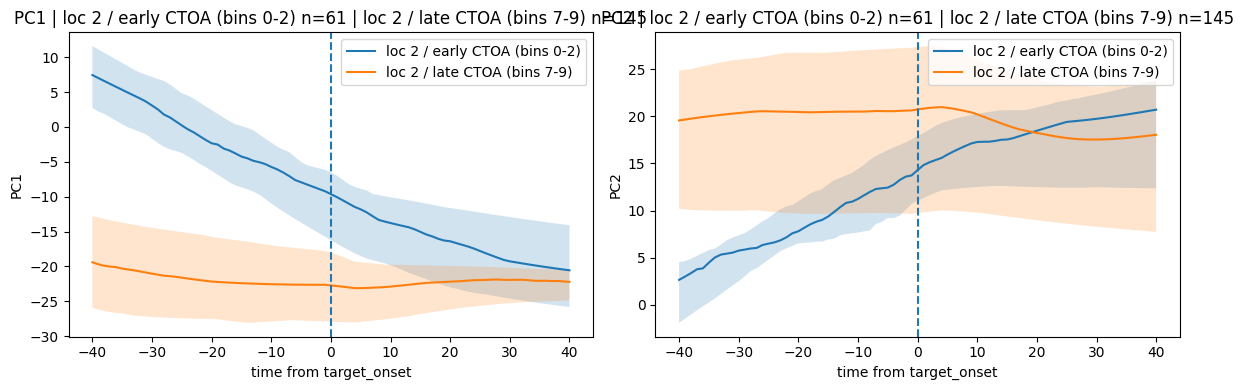

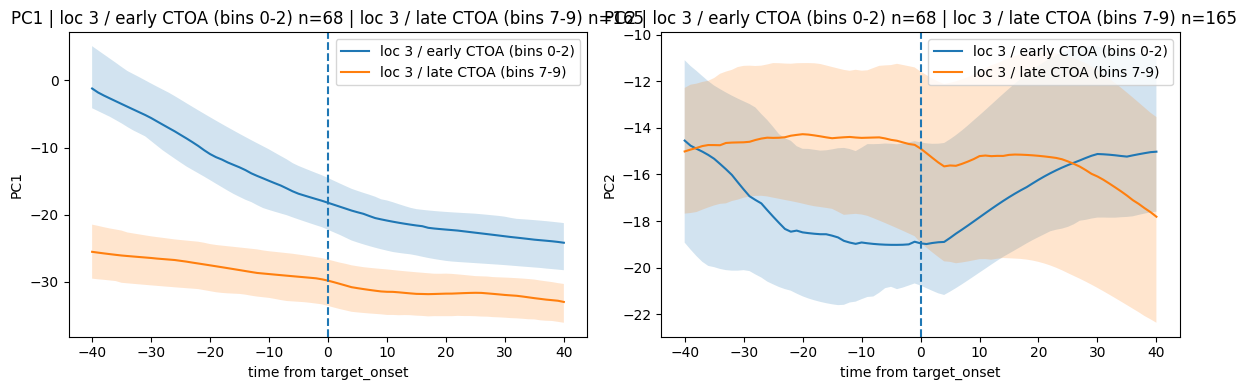

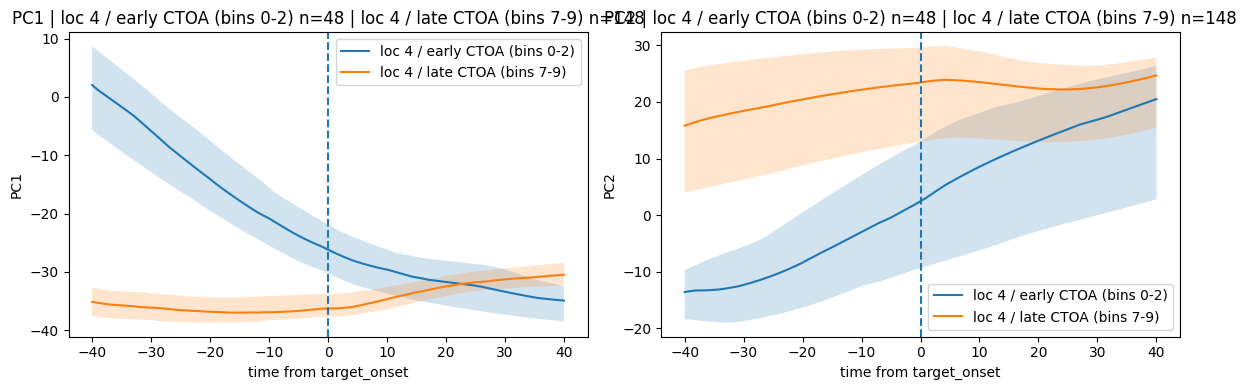

In [18]:
for loc in range(1, 5):
    plot_two_group_pc_timecourses(
        trials,
        trial_proj,
        align_key="target_onset",
        window_before=40,
        window_after=40,
        group1_kwargs={"train_outcome": "correct", "target_loc": loc, "ctoa_bin_max": 2},
        group2_kwargs={"train_outcome": "correct", "target_loc": loc, "ctoa_bin_min": 7},
        group1_label=f"loc {loc} / early CTOA (bins 0-2)",
        group2_label=f"loc {loc} / late CTOA (bins 7-9)",
        stat_mode="median",
        q_low=25,
        q_high=75,
    )

## CTOA x distractor presence

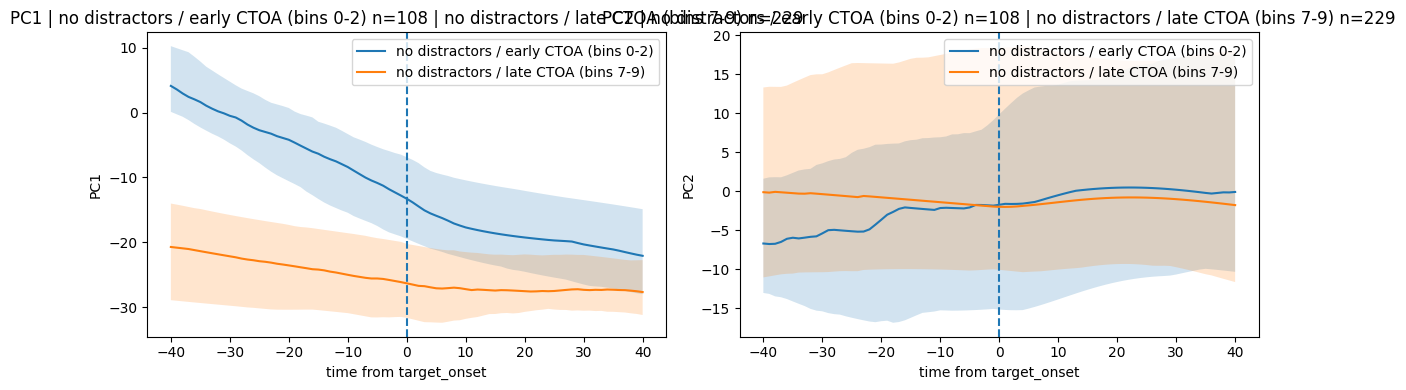

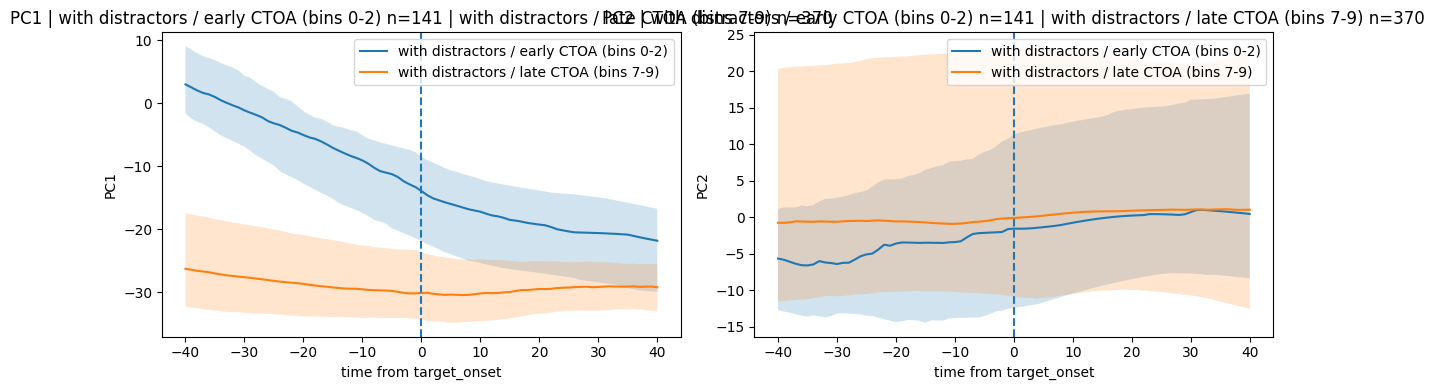

In [19]:
for has_d, label in [(False, "no distractors"), (True, "with distractors")]:
    plot_two_group_pc_timecourses(
        trials,
        trial_proj,
        align_key="target_onset",
        window_before=40,
        window_after=40,
        group1_kwargs={
            "train_outcome": "correct",
            "has_distractors": has_d,
            "ctoa_bin_max": 2,
        },
        group2_kwargs={
            "train_outcome": "correct",
            "has_distractors": has_d,
            "ctoa_bin_min": 7,
        },
        group1_label=f"{label} / early CTOA (bins 0-2)",
        group2_label=f"{label} / late CTOA (bins 7-9)",
        stat_mode="median",
        q_low=25,
        q_high=75,
    )

## Spatial separation analysis

Does the network represent target location in its hidden state?

In [ ]:
trials_spatial = collect_trials(model, make_env_stage2, n_trials=2000, device=device)
print(Counter(tr["train_outcome"] for tr in trials_spatial))

In [ ]:
trials_correct = filter_trials(trials_spatial, outcome="correct")
print("correct:", len(trials_correct))

res_pre = plot_spatial_separation_pca(
    trials_correct, align_key="target_onset", window_ms=(-300, 0)
)
res_post = plot_spatial_separation_pca(
    trials_correct, align_key="target_onset", window_ms=(100, 300)
)

print_centroid_distances(res_pre, name="Pre-target")
print_centroid_distances(res_post, name="Post-target")

In [ ]:
trials_hit = filter_trials(trials_spatial, outcome="correct", require_distractors=True)
trials_fa = filter_trials(trials_spatial, outcome="false_alarm", require_distractors=True)
print(f"hit (distractor): {len(trials_hit)},  FA (distractor): {len(trials_fa)}")

compare_spatial_separation(trials_hit, trials_fa, label_A="hit", label_B="false_alarm")

In [ ]:
trials_miss = filter_trials(trials_spatial, outcome="miss")
print("miss:", len(trials_miss))

if len(trials_miss) > 0:
    res_miss_pre = plot_spatial_separation_pca(
        trials_miss, align_key="target_onset", window_ms=(-300, 0)
    )
    res_miss_post = plot_spatial_separation_pca(
        trials_miss, align_key="target_onset", window_ms=(100, 300)
    )
    print_centroid_distances(res_miss_pre, name="Miss pre-target")
    print_centroid_distances(res_miss_post, name="Miss post-target")
else:
    print("Not enough miss trials to plot spatial separation.")

## Spatial sheet visualisation

Grid: 12x12  max_dist = 15.6 nodes  scale = 0.177
tau_EE: 8.0 → 1.41  |  p(max_dist) = 0.0000  (target < 0.05)
tau_IE: 10.0 → 1.77  |  p(max_dist) = 0.0002
tau_EI: 20.0 → 3.54  |  p(max_dist) = 0.0123
tau_II: 20.0 → 3.54  |  p(max_dist) = 0.0123



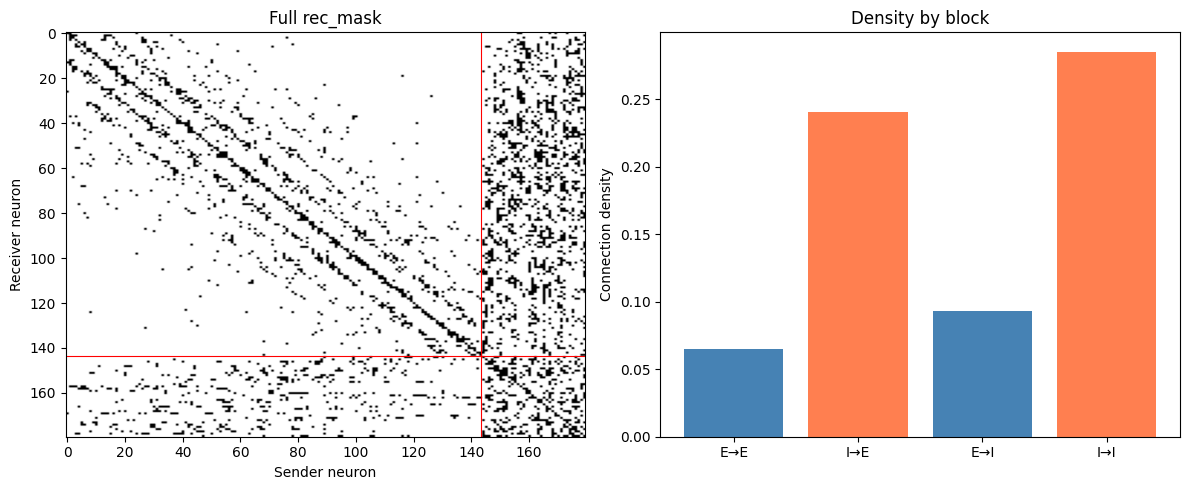

In [20]:
fig = plot_connectivity_matrix(model)
plt.show()

In [21]:
delay_h = []
for tr in trials:
    if tr["train_outcome"] != "correct":
        continue
    h_seq = tr["h"]  # [T, H]
    onset = tr.get("target_onset", h_seq.shape[0] // 2)
    cue = tr.get("cue_onset", max(0, onset - 10))
    window = h_seq[cue:onset]
    if window.shape[0] > 0:
        delay_h.append(window.mean(0))

h_mean = torch.tensor(np.stack(delay_h).mean(0))  # [H]
fig = plot_spatial_map(model, h_mean, title="Delay period")
plt.show()

AttributeError: 'BioLeakyRNNTopo' object has no attribute 'e_coords'

## Topographic W_in: before vs after training

Visualize the initial topographic W_in (fresh model) and the trained
W_in side-by-side to see how training reshaped the spatial channels.


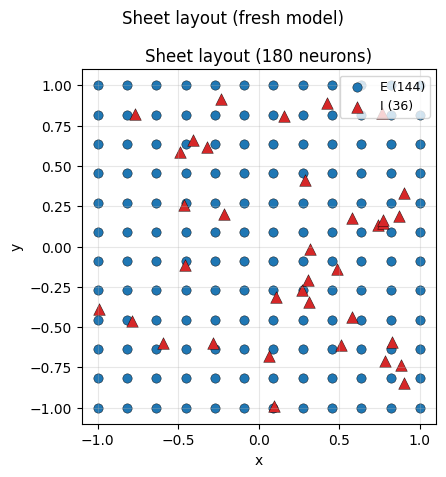

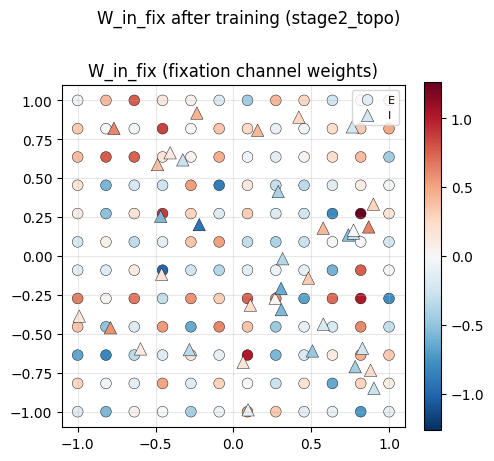

In [22]:
m_fresh = make_model()
fig1 = plot_sheet_layout(m_fresh)
fig1.suptitle("Sheet layout (fresh model)", y=1.05)
plt.show()

fig2 = plot_fix_weights(model)
fig2.suptitle("W_in_fix after training (stage2_topo)", y=1.05)
plt.show()

del m_fresh